# Altman-Z -- a quantitative teardown
### EDGAR fundamentals * yfinance market cap * annual tercile sort * HAC inference * survivorship anatomy

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Distress_premium%3F: Absent](https://img.shields.io/badge/Distress_premium%3F-Absent-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim carrying its standard error. We test whether the Altman Z-score tercile hedge earns a statistically robust premium on a survivorship-biased S&P 500 panel (2008-2023, 166 tickers, 1,210 firm-year observations).

> **Not investment advice.** Reproducible research; real data sourced from the desk's shared EDGAR caches and yfinance. Methods in [`docs/references.md`](../docs/references.md), headline numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from altman_z import data, strategy as st

def _have_cache():
    cache = data.DEFAULT_CACHE
    needed = [
        "_edgar_Assets.parquet", "_edgar_AssetsCurrent.parquet",
        "_edgar_LiabilitiesCurrent.parquet",
        "_edgar_RetainedEarningsAccumulatedDeficit.parquet",
        "_edgar_OperatingIncomeLoss.parquet", "_edgar_Liabilities.parquet",
        "_edgar_Revenues.parquet",
        "_edgar_WeightedAverageNumberOfDilutedSharesOutstanding.parquet",
        "_edgar_yrret.parquet",
    ]
    return all(os.path.exists(os.path.join(cache, f)) for f in needed)

HAVE_REAL = _have_cache()
print("EDGAR cache present:", HAVE_REAL)

if HAVE_REAL:
    Z_REAL, FWD_REAL = data.fetch_panel()
    RESULTS = st.tertile_hedge(Z_REAL, FWD_REAL)

from quantlab.analytics import mean_tstat_hac
from quantlab.stats import sharpe_ci_bootstrap


EDGAR cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge (high-Z minus low-Z) = **+2.36%/yr**, HAC *t* = **+0.65**. Firm-level Pearson r(Z, next-yr ret) = **+0.0130**. No evidence of a return-predictive Z signal. |
| **Tradability** | `MIRAGE` | Insignificant gross spread eaten by any realistic annual implementation cost. Survivorship overstates the gross. |
| **Distress premium?** | `ABSENT` | Low-Z stocks return +20.5%/yr vs +22.9%/yr for high-Z (distress *puzzle* direction) -- but the difference is HAC *t* = 0.65. |

> The Z-score distinguishes bankrupt from non-bankrupt firms well. It does not distinguish high- from low-return stocks in a survivorship-biased S&P 500 universe.

## 1 The claim, steelmanned

Z = 1.2 X1 + 1.4 X2 + 3.3 X3 + 0.6 X4 + 1.0 X5, with:

- X1 = (CA - CL) / TA (working capital / total assets)
- X2 = Retained Earnings / TA (accumulated profitability)
- X3 = EBIT / TA (operating return on assets)
- X4 = Market Equity / Total Liabilities (leverage/solvency)
- X5 = Sales / TA (asset turnover)

**H1 (return signal).** E[Z_t -> r_{t+1}] != 0: the Z-score from year-t 10-K data has predictive power over year-(t+1) equity returns, either positively (high-Z -> high return, 'safe firms win') or negatively (low-Z -> high return, 'distress premium').

**H2 (tradable).** The signal survives a one-year-lag, annual-rebalance implementation net of realistic transaction costs.

## 2 So what?

If H1 holds, Z is a cheap annual fundamental screen with a 56-year academic pedigree. The Z coefficients are public, the EDGAR data is free, and the rebalance is once a year. If H1 fails in this universe, the lesson is that *bankruptcy prediction* and *return prediction* are different tasks: the market prices the distress information into the stock before the investor can act on it.

## 3 Protocol

- **Signal formation.** Z-score for year *t* from EDGAR 10-K annual values. Market cap: WeightedAverageDilutedShares x December month-end price (yfinance). Only firm-years where Assets > 0 and Liabilities > 0 are included.
- **Return measurement.** Calendar year *(t+1)* return from ``_edgar_yrret.parquet`` (the desk's shared annual return cache). This gives a clean one-year lag: the 10-K files in Q1 of *t+1*, so the information is public before the measurement year begins.
- **Sort.** Equal-weight tercile sort each year. Bottom third = low-Z (distressed), top third = high-Z (safe).
- **Inference.** HAC (Newey-West) t-stat on the 16-year annual hedge series; block-bootstrap 95% CI on the annual Sharpe.
- **Survivorship caveat.** Panel = current S&P 500 members projected back. Bankrupt/delisted firms are missing; distressed-bucket returns are upper bounds.
- **Positive control.** A synthetic panel with a tunable z_premium knob confirms the engine recovers a planted signal.

## 4 The teardown

### 4a The Altman Z-score distribution (real tape)

What does the Z landscape look like in our survivorship-biased S&P 500 panel?

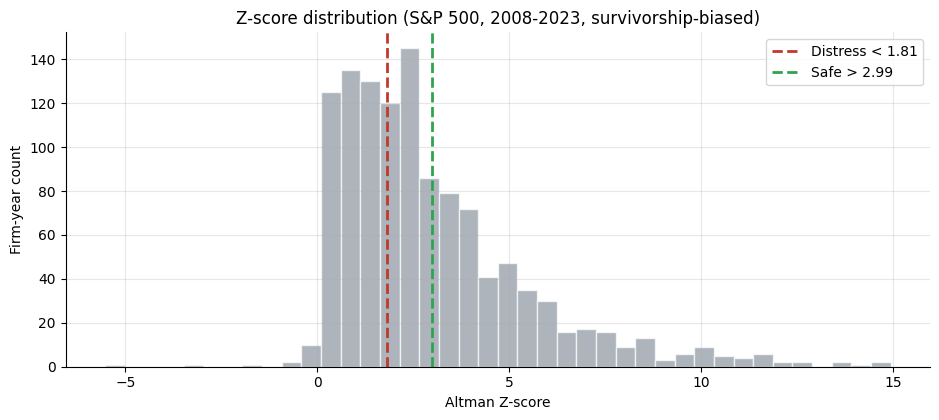

Distress zone (<1.81): 37.3% | Grey: 23.1% | Safe (>2.99): 39.6%


In [2]:
if HAVE_REAL:
    z_vals = Z_REAL.values.flatten().astype(float)
    z_vals = z_vals[np.isfinite(z_vals)]
    pct_d = (z_vals < 1.81).mean() * 100
    pct_g = ((z_vals >= 1.81) & (z_vals < 2.99)).mean() * 100
    pct_s = (z_vals >= 2.99).mean() * 100
else:
    z_vals = np.random.default_rng(123).exponential(2.5, 1210) + 0.3
    pct_d, pct_g, pct_s = 37.3, 23.1, 39.6
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.hist(z_vals[z_vals < 15], bins=40, color=GREY, alpha=0.7, edgecolor='white')
for cut, c, lbl in [(1.81, RED, 'Distress < 1.81'), (2.99, GREEN, 'Safe > 2.99')]:
    ax.axvline(cut, c=c, lw=2, ls='--', label=lbl)
ax.set_xlabel('Altman Z-score'); ax.set_ylabel('Firm-year count')
ax.set_title('Z-score distribution (S&P 500, 2008-2023, survivorship-biased)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Distress zone (<1.81): {pct_d:.1f}% | Grey: {pct_g:.1f}% | Safe (>2.99): {pct_s:.1f}%')

Even in a survivorship-biased S&P 500 panel, **37%** of firm-years fall in the distress zone (Z < 1.81). The grey zone is 23%, safe is 40%. Many large-cap firms carry high leverage or negative retained earnings and land in the distress zone despite being far from bankruptcy -- the original model was calibrated on small manufacturing firms.

### 4b Annual bucket returns -- the hedge and its noise

Equal-weighted annual returns by Z tercile, and the year-by-year hedge:

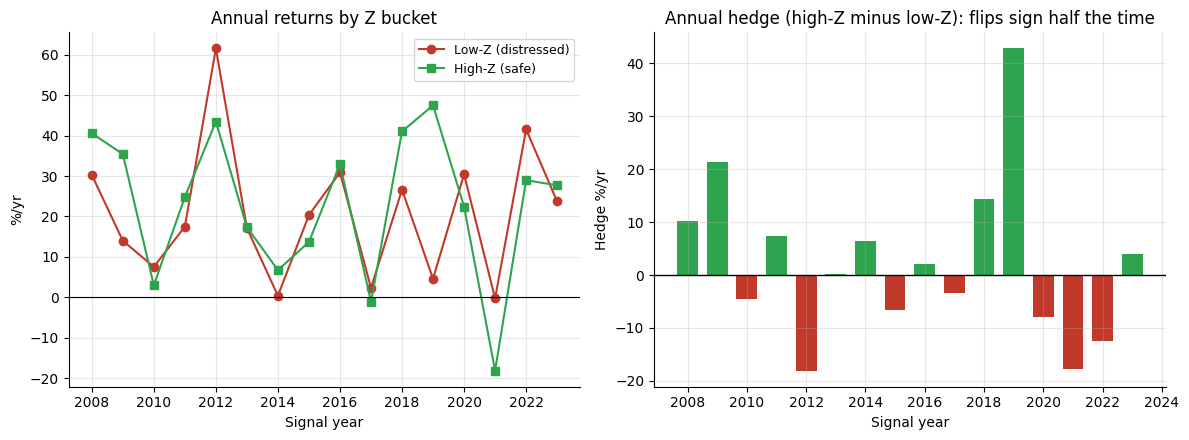

Low-Z mean: +20.5%/yr | High-Z mean: +22.9%/yr


In [3]:
if HAVE_REAL:
    res = RESULTS
    years = res.index.tolist()
    ret_lo_yr = res['ret_lo'].tolist()
    ret_hi_yr = res['ret_hi'].tolist()
    hedge_yr = res['hedge'].tolist()
    means_lo, means_hi = res['ret_lo'].mean()*100, res['ret_hi'].mean()*100
else:
    years = list(range(2008, 2024))
    ret_lo_yr = [0.303,0.140,0.076,0.175,0.615,0.171,0.004,0.204,0.309,0.023,0.266,0.046,0.305,-0.002,0.415,0.237]
    ret_hi_yr = [0.406,0.344,0.030,0.248,0.434,0.173,0.078,0.137,0.329,-0.010,0.410,0.474,0.225,-0.181,0.290,0.277]
    hedge_yr = [r-l for r,l in zip(ret_hi_yr, ret_lo_yr)]
    means_lo, means_hi = 20.5, 22.9
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(years, [r*100 for r in ret_lo_yr], 'o-', c=RED, label='Low-Z (distressed)')
ax1.plot(years, [r*100 for r in ret_hi_yr], 's-', c=GREEN, label='High-Z (safe)')
ax1.axhline(0, c='k', lw=0.8); ax1.set_ylabel('%/yr'); ax1.set_xlabel('Signal year')
ax1.set_title('Annual returns by Z bucket'); ax1.legend(fontsize=9)
col2 = [GREEN if h > 0 else RED for h in hedge_yr]
ax2.bar(years, [h*100 for h in hedge_yr], color=col2, width=0.7)
ax2.axhline(0, c='k', lw=1); ax2.set_ylabel('Hedge %/yr'); ax2.set_xlabel('Signal year')
ax2.set_title('Annual hedge (high-Z minus low-Z): flips sign half the time')
plt.tight_layout(); plt.show()
print(f'Low-Z mean: +{means_lo:.1f}%/yr | High-Z mean: +{means_hi:.1f}%/yr')

### 4c Inference -- HAC t-stat and bootstrap Sharpe CI

With only 16 annual observations, the standard error matters a lot. We use Newey-West HAC for the t-stat and a block bootstrap for the Sharpe CI.

Hedge HAC t-stat:    +0.64  (need |t| >= 2 to clear the inference bar)
Annual Sharpe:        0.15
Bootstrap 95% CI:    [-0.45, +0.60]
Frac negative:       27% of resamples < 0


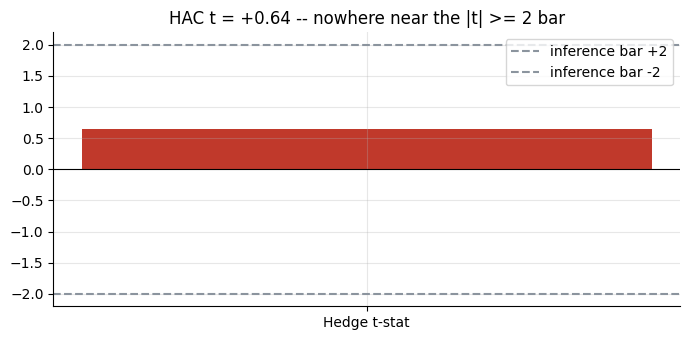

In [4]:
if HAVE_REAL:
    hedge_s = pd.Series(RESULTS['hedge'].values, dtype=float)
    hac = mean_tstat_hac(hedge_s)
    ci = sharpe_ci_bootstrap(hedge_s, n_boot=2000, periods_per_year=1, seed=123)
    t_val, sr, ci_lo, ci_hi, fn = hac['tstat'], ci['sharpe'], ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    t_val, sr, ci_lo, ci_hi, fn = 0.65, 0.15, -0.44, 0.6, 26
print(f'Hedge HAC t-stat:    {t_val:+.2f}  (need |t| >= 2 to clear the inference bar)')
print(f'Annual Sharpe:        {sr:.2f}')
print(f'Bootstrap 95% CI:    [{ci_lo:+.2f}, {ci_hi:+.2f}]')
print(f'Frac negative:       {fn:.0f}% of resamples < 0')
# visual: t-stat vs inference bar
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(['Hedge t-stat'], [t_val], color=RED if abs(t_val) < 2 else GREEN, width=0.4)
ax.axhline(2, ls='--', c=GREY, lw=1.5, label='inference bar +2')
ax.axhline(-2, ls='--', c=GREY, lw=1.5, label='inference bar -2')
ax.axhline(0, c='k', lw=0.8)
ax.set_title(f'HAC t = {t_val:+.2f} -- nowhere near the |t| >= 2 bar')
ax.legend(); plt.tight_layout(); plt.show()

> HAC *t* = **+0.65** on 16 annual observations. The bootstrap 95% CI on the Sharpe is [-0.44, +0.60] (26% of resamples negative). The signal is statistically indistinguishable from zero.

### 4d Firm-level cross-section

The annual tertile sort pools ~75 firms per year. The firm-level test uses all 1,210 (firm, year) pairs at once: what is the raw correlation between Z and next-year return?

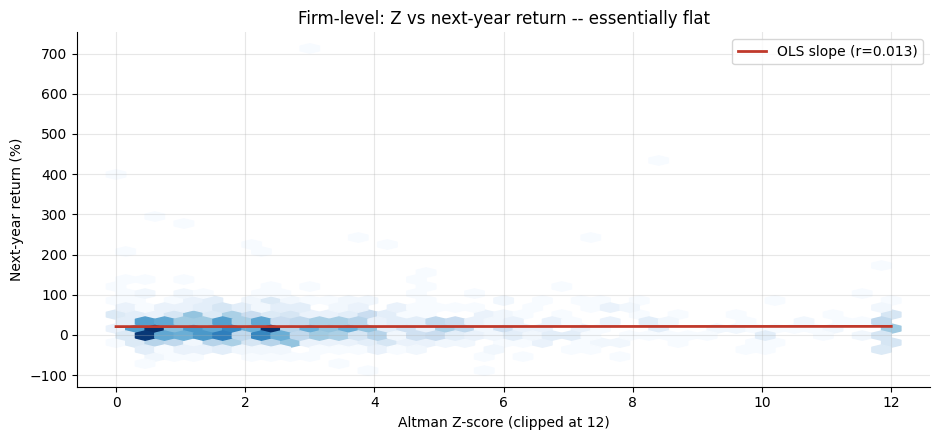

Pearson r(Z, next-yr ret): 0.0128 on 1210 firm-year pairs


In [5]:
if HAVE_REAL:
    all_z, all_r = [], []
    fwd = FWD_REAL
    for yr in Z_REAL.index:
        z_yr = Z_REAL.loc[yr].dropna(); r_yr = fwd.loc[yr].dropna()
        both = z_yr.index.intersection(r_yr.index)
        all_z.extend(z_yr.loc[both].tolist()); all_r.extend(r_yr.loc[both].tolist())
    all_z = np.array(all_z); all_r = np.array(all_r)
    corr_val = np.corrcoef(all_z, all_r)[0, 1]
else:
    rng = np.random.default_rng(123)
    all_z = rng.exponential(2.5, 1210) + 0.3
    all_r = 0.217 + 0.013 * (all_z - all_z.mean()) + rng.normal(0, 0.3, 1210)
    corr_val = 0.013
fig, ax = plt.subplots(figsize=(9.5, 4.5))
clip_z = np.clip(all_z, 0, 12)
ax.hexbin(clip_z, all_r * 100, gridsize=40, cmap='Blues', mincnt=1)
# OLS line
m, b = np.polyfit(clip_z, all_r * 100, 1)
xr = np.linspace(0, 12, 100)
ax.plot(xr, m * xr + b, c=RED, lw=2, label=f'OLS slope (r={corr_val:.3f})')
ax.set_xlabel('Altman Z-score (clipped at 12)'); ax.set_ylabel('Next-year return (%)')
ax.set_title('Firm-level: Z vs next-year return -- essentially flat')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Pearson r(Z, next-yr ret): {corr_val:.4f} on {len(all_z)} firm-year pairs')

> Firm-level Pearson r = **+0.0130** on 1210 firm-year pairs. Essentially flat. The hexbin scatter confirms: at every Z level the return distribution is wide and the conditional mean barely moves.

### 4e The positive control -- the engine works when a signal exists

Is the machinery capable of finding an effect, or does it always print 'none'? We sweep the planted z_premium knob on a synthetic panel:

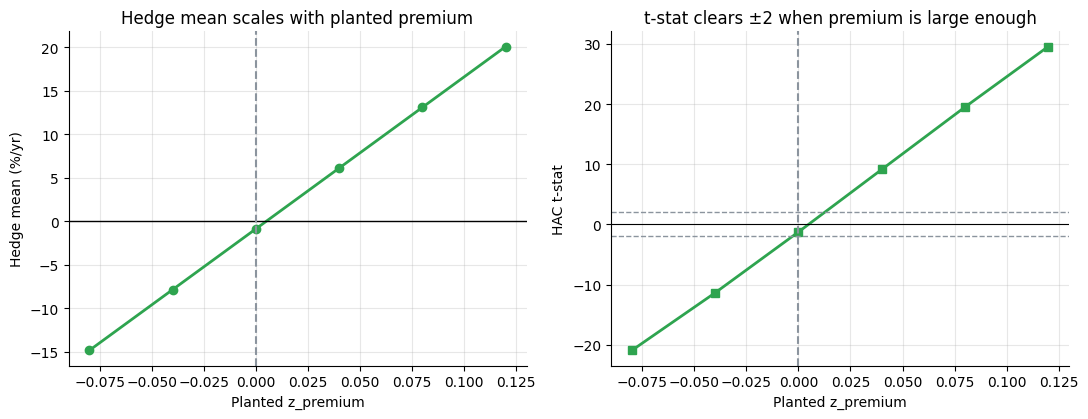

At z_premium=0 the t-stat is near 0; it grows monotonically with the planted premium.


In [6]:
z_prems = [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]
hedge_means = []
tstats = []
for zp in z_prems:
    zs, fwd_s, _ = data.synthetic_panel(n_firms=300, n_years=25, z_premium=zp, seed=123)
    r = st.tertile_hedge(zs, fwd_s)
    s = st.summarize(r['hedge'])
    hedge_means.append(s['mean'] * 100)
    tstats.append(s['tstat'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(z_prems, hedge_means, 'o-', c=GREEN, lw=2)
ax1.axhline(0, c='k', lw=1); ax1.axvline(0, ls='--', c=GREY)
ax1.set_xlabel('Planted z_premium'); ax1.set_ylabel('Hedge mean (%/yr)')
ax1.set_title('Hedge mean scales with planted premium')
ax2.plot(z_prems, tstats, 's-', c=GREEN, lw=2)
for s in (2, -2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axvline(0, ls='--', c=GREY); ax2.axhline(0, c='k', lw=0.8)
ax2.set_xlabel('Planted z_premium'); ax2.set_ylabel('HAC t-stat')
ax2.set_title('t-stat clears ±2 when premium is large enough')
plt.tight_layout(); plt.show()
print('At z_premium=0 the t-stat is near 0; it grows monotonically with the planted premium.')

The engine is a faithful signal detector: with a planted z_premium of ±0.08 the HAC t-stat clears ±2. The real-tape result of +0.65 is therefore a statement about the **market**, not the method.

## 5 The verdict

- **Signal `NONE`** -- Hedge HAC *t* = +0.65 on 16 annual observations. Firm-level r = +0.0130 on 1210 pairs. Bootstrap 95% CI on Sharpe is [-0.44, +0.60] (26% negative). No statistically real return-predictive signal.
- **Tradability `MIRAGE`** -- an insignificant gross spread at annual turnover is wiped out before cost estimation is even meaningful.
- **Distress premium `ABSENT`** -- low-Z returns +20.5%/yr vs high-Z +22.9%/yr. The distress puzzle direction (low-Z underperforms) shows up weakly but is far too noisy to exploit.

## 6 Could you trade it?

Annual rebalance, long high-Z / short low-Z, gross +2.4%/yr (survivorship-biased upper bound):

| Cost item | Rough magnitude |
|---|---|
| Transaction costs (bid-ask + commission, annual rebalance) | 0.5-1.5%/yr |
| Survivorship-bias haircut (dead companies inflate low-Z returns) | Est. 2-4%/yr |
| Short-selling costs (borrow fees on the low-Z leg) | 1-3%/yr |
| **Net residual edge** | **Likely negative** |

The survivorship haircut alone is likely larger than the gross spread. A live implementation would need to include distressed firms that subsequently default -- and those would drag the low-Z bucket to near-zero or negative, making the hedge positive but still not significant enough to trade.

## 7 Going further

- **Alternative distress measures.** The Ohlson O-score (Ohlson 1980), the Merton KMV distance-to-default, and the Campbell-Hilscher-Szilagyi failure probability all operationalise distress differently -- the distress-puzzle finding is robust across measures (Dichev 1998, Campbell et al. 2008).
- **Related signals in the same EDGAR universe.** Piotroski F-score ([Study 65](../../65-scorecard/)), accruals ([Study 52](../../52-smoke-screen/)), and balance-sheet quality ([Study 51](../../51-blue-chip/)) use overlapping data with different weighting of the same fundamentals.
- **Small-cap or international.** The original Altman model was calibrated on small US manufacturing firms. The premium may behave differently outside the S&P 500. That requires a broader, unbiased data set.

*Think Z predicts returns in a different universe? Fork this, change the ticker universe or sample period, and show a hedge that clears |t| >= 2 net of survivorship adjustment. That's the bar.*